In [ ]:
# Author: Andrey Ovchinnikov
# Project: Student Performance ML
# Goal: Predict student grades based on study data

In [ ]:
# Student Performance Analysis & Prediction

In [ ]:
# Цель: проанализировать данные и предсказать оценку

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [250]:
df = pd.read_csv("/content/students_ml_practice.csv")

In [255]:
df.head()

,student_id,name,age,grade,hours_studied,attendance_percent,homework_done,club,city
0,1,Ivan,15,5,12,96,yes,robotics,Moscow
1,2,Anna,16,4,9,91,yes,art,Kazan
2,3,Oleg,15,3,4,78,no,football,Moscow
3,4,Maria,17,5,14,98,yes,science,Saint Petersburg
4,5,Nikita,16,2,2,65,no,none,Novosibirsk


In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   student_id          20 non-null     int64 
 1   name                20 non-null     object
 2   age                 20 non-null     int64 
 3   grade               20 non-null     int64 
 4   hours_studied       20 non-null     int64 
 5   attendance_percent  20 non-null     int64 
 6   homework_done       20 non-null     object
 7   club                20 non-null     object
 8   city                20 non-null     object
dtypes: int64(5), object(4)
memory usage: 1.5+ KB


In [257]:
df.describe()

,student_id,age,grade,hours_studied,attendance_percent
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,15.950000,3.850000,7.850000,85.400000
std,5.91608,0.825578,1.089423,4.068816,11.240903
min,1.00000,15.000000,2.000000,1.000000,60.000000
25%,5.75000,15.000000,3.000000,4.750000,78.750000
50%,10.50000,16.000000,4.000000,8.000000,88.500000
75%,15.25000,17.000000,5.000000,11.000000,94.250000
max,20.00000,17.000000,5.000000,15.000000,99.000000


In [253]:
# Гипотеза 1: больше часов → выше оценка
# Гипотеза 2: домашка → выше оценка

In [259]:
df[df['hours_studied'] > 10]['grade'].mean()

np.float64(5.0)

In [260]:
df[df['hours_studied'] <= 10]['grade'].mean()

np.float64(3.357142857142857)

In [261]:
df[df['homework_done'] == 'yes']['grade'].mean()

np.float64(4.538461538461538)

In [262]:
df[df['homework_done'] == 'no']['grade'].mean()

np.float64(2.5714285714285716)

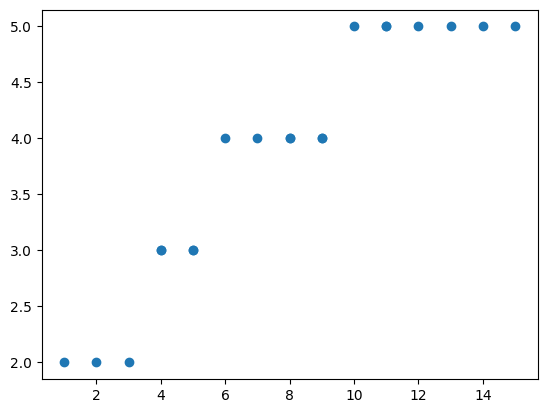

In [264]:
plt.scatter(df["hours_studied"], df["grade"])
plt.show()


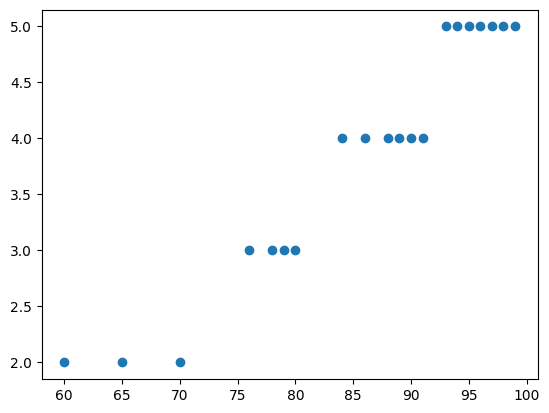

In [265]:
plt.scatter(df["attendance_percent"], df["grade"])
plt.show()

In [266]:
df["homework_done"] = df["homework_done"].map({
    "yes": 1,
    "no": 0
})

In [267]:
X = df[["hours_studied", "attendance_percent"]]
y = df["grade"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
mean_absolute_error(y_test, pred)

0.25888340003243665

In [268]:
X = df[["hours_studied", "attendance_percent", "homework_done"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)
mean_absolute_error(y_test, pred)

0.246985978162607

In [269]:
# 1. Больше часов → выше оценка
# 2. Домашка сильно влияет
# 3. Добавление признака улучшает модель

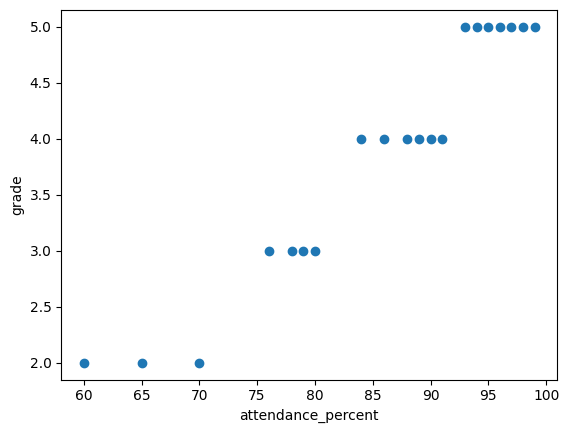

In [246]:
import matplotlib.pyplot as plt

plt.scatter(df["attendance_percent"], df["grade"])
plt.xlabel("attendance_percent")
plt.ylabel("grade")
plt.show()

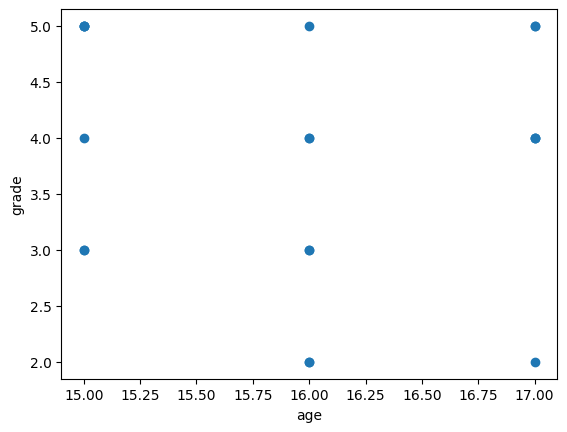

In [249]:
import matplotlib.pyplot as plt

plt.scatter(df["age"], df["grade"])
plt.xlabel("age")
plt.ylabel("grade")
plt.show()